# 3. Full benchmark: all grids, all coupling impedances

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WillemLam/unified-acdc-powerflow/blob/main/benchmarks/pandapower_acdc/03_full_benchmark.ipynb)

Notebooks 1 and 2 go through one grid each. This notebook runs the complete benchmark (about 4 minutes): the four
grids of W. Lambrichts and M. Paolone, "General and Unified Model of the Power Flow Problem in Multiterminal AC/DC Networks", IEEE Trans. Power Systems, 2024, [doi:10.1109/TPWRS.2024.3378926](https://doi.org/10.1109/TPWRS.2024.3378926), with pandapower's coupling impedance at 1e-4, 1e-3, 1e-2 and 1e-1 p.u. of the bus base.

unified-acdc-powerflow runs on each grid as in the paper, with the converters connected directly. pandapower runs
three times per grid and impedance:
1. on the grid as in the paper;
2. with the DC loads divided by `sn_mva` (pandapower 3.5.5 multiplies them by `sn_mva`);
3. as 2, with each converter that shares its bus with a voltage-controlling generator moved one short branch away
   (unified-acdc-powerflow gets this grid too, for the comparison).

Each pandapower run gets the initialisations `auto`, `dc` and `flat` and 100 iterations; a solution with a voltage
outside 0.8–1.2 p.u. counts as spurious.

In [1]:
# Setup. In Colab: download the repository and install pandapower 3.5.5.
# Locally: use the repository this notebook is in.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:
    if not Path("unified-acdc-powerflow").exists():
        !git clone -q https://github.com/WillemLam/unified-acdc-powerflow.git
    %cd unified-acdc-powerflow
    !pip install -q "pandapower==3.5.5" pyyaml
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists():
        root = root.parent
    os.chdir(root)
sys.path.insert(0, os.getcwd())

import logging, time, warnings
logging.getLogger("pandapower").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import pandapower as pp
from unified_acdc_powerflow import run_pf
from unified_acdc_powerflow.cases import load_case

def run_pandapower(net, init="auto"):
    """pandapower's own AC/DC power flow: a status line with the iterations and time reported by pandapower."""
    t0 = time.perf_counter()
    try:
        pp.runpp(net, init=init, max_iteration=100, tolerance_mva=1e-8)
    except Exception as err:
        return f"{type(err).__name__}: {str(err)[:70]} | time: {(time.perf_counter() - t0) * 1e3:.1f} ms"
    return f"converged | iterations: {net._ppc['iterations']} | time: {net._ppc['et'] * 1e3:.1f} ms"

def report(res):
    """The same status line for unified-acdc-powerflow."""
    return (f"{res.message} | iterations: {res.iterations} | max mismatch: {res.max_mismatch:.2e} | "
            f"time: {res.solve_time_s * 1e3:.1f} ms")

def with_coupling_impedance(net, z):
    """A copy of net for pandapower: every converter behind a coupling impedance of z p.u. (AC: r = x; DC: r)."""
    n = pp.from_json_string(pp.to_json(net))
    for i, v in n.vsc.iterrows():
        z_ac = z * n.bus.vn_kv[v.bus] ** 2 / n.sn_mva
        z_dc = z * n.bus_dc.vn_kv[v.bus_dc] ** 2 / n.sn_mva
        n.vsc.loc[i, ["r_ohm", "x_ohm", "r_dc_ohm"]] = [z_ac, z_ac, z_dc]
    return n

print("pandapower", pp.__version__)


pandapower 3.5.5


## Step 1: helpers

In [2]:
import matplotlib.pyplot as plt

def pandapower_result(n):
    """pandapower's best result over the initialisations: (status, AC |V| per bus, DC V per bus)."""
    status = "not converged"
    for init in ("auto", "dc", "flat"):
        try:
            pp.runpp(n, init=init, max_iteration=100, tolerance_mva=1e-8)
        except Exception as err:
            if status == "not converged" and not str(err).startswith("Power Flow"):
                status = f"error: {type(err).__name__}"
            continue
        v = pd.concat([n.res_bus.vm_pu, n.res_bus_dc.vm_pu])
        if 0.8 <= v.min() and v.max() <= 1.2:
            return "converged", n.res_bus.vm_pu.copy(), n.res_bus_dc.vm_pu.copy()
        status = f"spurious (V {v.min():.2f}..{v.max():.2f} p.u.)"
    return status, None, None

def dc_loads_corrected(n):
    """Cancel pandapower 3.5.5's scaling of the DC loads by sn_mva."""
    n.load_dc["p_dc_mw"] = n.load_dc.p_dc_mw / n.sn_mva
    return n

def converters_on_gen_buses(net):
    return sorted(set(net.vsc.bus) & set(net.gen.bus[net.gen.in_service]))

def with_gen_bus_converters_moved(net):
    """Each converter on the bus of a voltage-controlling generator moves to a new busbar one short branch away
    (r = 0.01, x = 1e-4 p.u.)."""
    for i in net.vsc.index[net.vsc.bus.isin(converters_on_gen_buses(net))]:
        b = net.vsc.bus[i]
        z_base = net.bus.vn_kv[b] ** 2 / net.sn_mva
        busbar = pp.create_bus(net, net.bus.vn_kv[b], name=f"busbar of {net.vsc.name[i]}")
        pp.create_line_from_parameters(net, b, busbar, 1.0, 0.01 * z_base, 1e-4 * z_base, 0.0, 99.0)
        net.vsc.at[i, "bus"] = busbar
    return net

def voltage_difference(net, res, vm, vdc):
    """Largest AC and DC voltage difference between pandapower's solution and unified-acdc-powerflow's."""
    if vm is None:
        return np.nan, np.nan
    m = res.model
    return (max(abs(vm[b] - abs(res.E_ac[m.bus_lookup[b]])) for b in net.bus.index),
            max(abs(vdc[b] - res.E_dc[m.bus_dc_lookup[b]]) for b in net.bus_dc.index))

def control_run(net, res):
    """pandapower on the AC grid only, each converter replaced by a fixed injection from unified-acdc-powerflow."""
    n = pp.from_json_string(pp.to_json(net))
    for (i, v), p, q in zip(n.vsc.iterrows(), res.conv_p_ac, res.conv_q_ac):
        pp.create_sgen(n, v.bus, p_mw=p * n.sn_mva, q_mvar=q * n.sn_mva)
    for tab in ("vsc", "line_dc", "load_dc", "source_dc", "bus_dc"):
        n[tab] = n[tab].iloc[0:0]
    try:
        pp.runpp(n, max_iteration=100)
        return "converged"
    except Exception as err:
        return type(err).__name__

## Step 2: run the benchmark

In [3]:
GRIDS = {"IEEE 57+14, 2 HVDC grids": "ieee57_14_hvdc", "IEEE 30, 2 HVDC grids": "ieee30_hvdc",
         "PEGASE 1354, 2 HVDC grids": "pegase_hvdc", "EPFL microgrid (EMTP-RV setpoints)": "microgrid_emtp"}
Z_PU = (1e-4, 1e-3, 1e-2, 1e-1)   # pandapower's coupling impedance, p.u. of the bus base
RUNS = ["1. as in the paper", "2. DC loads corrected", "3. and converters next to generators moved"]

rows, grids, t0 = [], [], time.perf_counter()
for grid, case in GRIDS.items():
    net = load_case(case)
    ours = run_pf(net)
    gen = converters_on_gen_buses(net)
    moved = with_gen_bus_converters_moved(load_case(case))
    ours_moved = run_pf(moved)
    grids.append({"grid": grid, "AC buses": len(net.bus), "DC buses": len(net.bus_dc), "converters": len(net.vsc),
                  "DC loads": len(net.load_dc), "converters on generator buses": gen,
                  "unified-acdc-powerflow": report(ours), "pandapower control run": control_run(net, ours)})
    for z in Z_PU:
        s1, vm, vdc = pandapower_result(with_coupling_impedance(net, z))
        dv_as_is = voltage_difference(net, ours, vm, vdc)
        s2, vm, vdc = (pandapower_result(dc_loads_corrected(with_coupling_impedance(net, z))) if len(net.load_dc)
                       else ("(no DC load)", vm, vdc))
        dv = voltage_difference(net, ours, vm, vdc)
        s3 = "(no converter on a generator bus)"
        if gen:
            s3, vm, vdc = pandapower_result(dc_loads_corrected(with_coupling_impedance(moved, z)))
            dv = voltage_difference(moved, ours_moved, vm, vdc)
        rows.append({"grid": grid, "z (p.u.)": z, RUNS[0]: s1, RUNS[1]: s2, RUNS[2]: s3,
                     "dV AC as is": dv_as_is[0], "dV DC as is": dv_as_is[1], "dV AC": dv[0], "dV DC": dv[1]})
    print(f"{grid}: done after {time.perf_counter() - t0:.0f} s")
results, grids = pd.DataFrame(rows), pd.DataFrame(grids)
grids[["grid", "AC buses", "DC buses", "converters", "DC loads", "converters on generator buses"]]

IEEE 57+14, 2 HVDC grids: done after 45 s


IEEE 30, 2 HVDC grids: done after 84 s


PEGASE 1354, 2 HVDC grids: done after 172 s


EPFL microgrid (EMTP-RV setpoints): done after 181 s


,grid,AC buses,DC buses,converters,DC loads,converters on generator buses
0,"IEEE 57+14, 2 HVDC grids",72,10,8,1,[202]
1,"IEEE 30, 2 HVDC grids",30,8,6,2,[102]
2,"PEGASE 1354, 2 HVDC grids",1354,5,5,0,"[352, 7282]"
3,EPFL microgrid (EMTP-RV setpoints),18,8,4,4,[]


## Step 3: does pandapower converge?

Per grid, the three pandapower runs (rows) at each coupling impedance (columns):

In [4]:
status = results.melt(id_vars=["grid", "z (p.u.)"], value_vars=RUNS, var_name="pandapower run", value_name="status")
status.pivot_table(index=["grid", "pandapower run"], columns="z (p.u.)", values="status", aggfunc="first", sort=False)

z (p.u.)                                                                                                  0.0001  \
grid                               pandapower run                                                                  
IEEE 57+14, 2 HVDC grids           1. as in the paper                                              not converged   
                                   2. DC loads corrected                                           not converged   
                                   3. and converters next to generators moved                          converged   
IEEE 30, 2 HVDC grids              1. as in the paper                                              not converged   
                                   2. DC loads corrected                                           not converged   
                                   3. and converters next to generators moved                          converged   
PEGASE 1354, 2 HVDC grids          1. as in the paper                                              not converged   
                                   2. DC loads corrected                                            (no DC load)   
                                   3. and converters next to generators moved                          converged   
EPFL microgrid (EMTP-RV setpoints) 1. as in the paper                                                  converged   
                                   2. DC loads corrected                                               converged   
                                   3. and converters next to generators moved  (no converter on a generator bus)   

z (p.u.)                                                                                                  0.0010  \
grid                               pandapower run                                                                  
IEEE 57+14, 2 HVDC grids           1. as in the paper                                              not converged   
                                   2. DC loads corrected                                           not converged   
                                   3. and converters next to generators moved                          converged   
IEEE 30, 2 HVDC grids              1. as in the paper                                              not converged   
                                   2. DC loads corrected                                           not converged   
                                   3. and converters next to generators moved                          converged   
PEGASE 1354, 2 HVDC grids          1. as in the paper                                        error: RuntimeError   
                                   2. DC loads corrected                                            (no DC load)   
                                   3. and converters next to generators moved                          converged   
EPFL microgrid (EMTP-RV setpoints) 1. as in the paper                                                  converged   
                                   2. DC loads corrected                                               converged   
                                   3. and converters next to generators moved  (no converter on a generator bus)   

z (p.u.)                                                                                                  0.0100  \
grid                               pandapower run                                                                  
IEEE 57+14, 2 HVDC grids           1. as in the paper                                              not converged   
                                   2. DC loads corrected                                           not converged   
                                   3. and converters next to generators moved                          converged   
IEEE 30, 2 HVDC grids              1. as in the paper                                              not converged   
                                   2. DC loads correct

On the three HVDC grids, pandapower does not converge as in the paper, nor with the DC loads corrected, at any
coupling impedance. Once the converters next to generators are moved one branch away, it converges everywhere.
The microgrid has no converter on a generator bus: there pandapower converges, but with the DC loads scaled.

## Step 4: where pandapower converges, how far is it from unified-acdc-powerflow?

The largest AC voltage difference to unified-acdc-powerflow on the same grid, for the last pandapower run that
converges (run 3 on the HVDC grids, run 2 on the microgrid):

z (p.u.),0.000100,0.001000,0.010000,0.100000
grid,,,,
"IEEE 57+14, 2 HVDC grids",1.9e-06,1.9e-05,1.9e-04,2.0e-03
"IEEE 30, 2 HVDC grids",1.2e-07,1.2e-06,1.2e-05,1.1e-04
"PEGASE 1354, 2 HVDC grids",2.8e-10,2.8e-09,2.8e-08,2.8e-07
EPFL microgrid (EMTP-RV setpoints),3.5e-06,7.6e-06,5.0e-05,4.8e-04


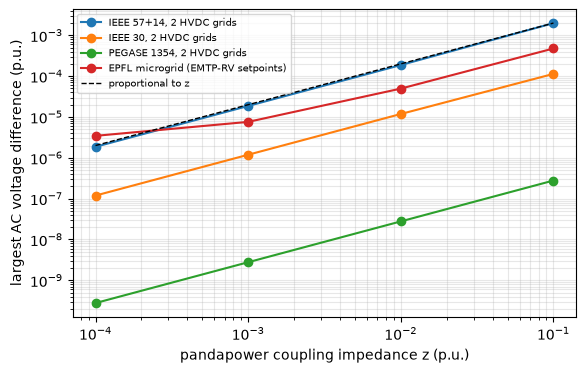

largest DC voltage difference on the three HVDC grids: 6.1e-13 p.u.


In [5]:
dv = results.pivot_table(index="grid", columns="z (p.u.)", values="dV AC", sort=False)
display(dv.style.format("{:.1e}"))

fig, ax = plt.subplots(figsize=(6.5, 4))
for grid, g in results.groupby("grid", sort=False):
    ax.loglog(g["z (p.u.)"], g["dV AC"], "o-", label=grid)
z = np.array([1e-4, 1e-1])
ax.loglog(z, 2e-2 * z, "k--", lw=1, label="proportional to z")
ax.set_xlabel("pandapower coupling impedance z (p.u.)")
ax.set_ylabel("largest AC voltage difference (p.u.)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7)
plt.show()
hvdc = results.grid.str.contains("HVDC")
print(f"largest DC voltage difference on the three HVDC grids: {results['dV DC'][hvdc].max():.1e} p.u.")

Every line has slope 1: the difference is proportional to pandapower's coupling impedance and vanishes with it.
It comes from the impedance, not from a disagreement between the two models. unified-acdc-powerflow needs no
impedance; notebook 2 shows against EMTP-RV that none is needed.

Without the DC-load correction, pandapower's solution of the microgrid is much further off:

In [6]:
mg = results[results.grid.str.startswith("EPFL")]
pd.DataFrame({"z (p.u.)": mg["z (p.u.)"],
              "pandapower as is: AC / DC (p.u.)": [f"{a:.1e} / {b:.1e}" for a, b in zip(mg["dV AC as is"], mg["dV DC as is"])],
              "DC loads corrected: AC / DC (p.u.)": [f"{a:.1e} / {b:.1e}" for a, b in zip(mg["dV AC"], mg["dV DC"])]})

,z (p.u.),pandapower as is: AC / DC (p.u.),DC loads corrected: AC / DC (p.u.)
12,0.0001,4.0e-03 / 1.9e-03,3.5e-06 / 4.4e-06
13,0.0010,4.0e-03 / 1.9e-03,7.6e-06 / 4.4e-06
14,0.0100,4.0e-03 / 1.9e-03,5.0e-05 / 4.4e-06
15,0.1000,4.4e-03 / 1.9e-03,4.8e-04 / 4.4e-06


## Step 5: unified-acdc-powerflow, and the control run

unified-acdc-powerflow on each grid as in the paper. In the control run, each converter is replaced by a fixed
injection from unified-acdc-powerflow's solution: pandapower then solves every AC grid, so the AC data are fine and
its failures above come from the converters.

In [7]:
grids[["grid", "unified-acdc-powerflow", "pandapower control run"]]

,grid,unified-acdc-powerflow,pandapower control run
0,"IEEE 57+14, 2 HVDC grids",converged | iterations: 5 | max mismatch: 5.66...,converged
1,"IEEE 30, 2 HVDC grids",converged | iterations: 4 | max mismatch: 7.30...,converged
2,"PEGASE 1354, 2 HVDC grids",converged | iterations: 7 | max mismatch: 3.11...,converged
3,EPFL microgrid (EMTP-RV setpoints),converged | iterations: 4 | max mismatch: 5.70...,converged


**Takeaway.**
- On the three HVDC grids of the paper, pandapower 3.5.5 does not converge at any coupling impedance from 1e-4 to
  1e-1 p.u. unified-acdc-powerflow converges in 4–7 iterations, with the converters connected directly.
- The causes are isolated: with the DC loads corrected and only the converters next to generators moved,
  pandapower converges on every grid.
- The two models then agree, up to a difference proportional to pandapower's coupling impedance.
- On the microgrid pandapower converges, but its DC-load scaling puts it about 4e-3 p.u. off.

## Appendix: the pandapower-only reproducer

Writes the files in `reproducer/`, which `reproducer/reproduce.py` runs with pandapower alone: the three HVDC grids
with a coupling impedance of 1e-3 p.u., and a minimal DC-load case (one converter feeding a 5 MW DC load) with
`sn_mva` = 1 and 100.

In [8]:
from unified_acdc_powerflow.network import CONV_COLUMNS
out = Path("benchmarks/pandapower_acdc/reproducer")

def save_for_pandapower(n, file, label):
    """Plain pandapower JSON: only pandapower's own vsc columns, no results."""
    n = pp.from_json_string(pp.to_json(n))
    n.vsc = n.vsc.drop(columns=[c for c in CONV_COLUMNS if c in n.vsc])
    for tab in [t for t in n.keys() if t.startswith("res_")]:
        n[tab] = n[tab].iloc[0:0]
    n.name = label
    pp.to_json(n, str(out / f"{file}.json"))

for grid, case in list(GRIDS.items())[:3]:
    save_for_pandapower(with_coupling_impedance(load_case(case), 1e-3), f"{case}_z_1e-3",
                        f"{grid}, as in the paper, coupling impedance 1e-3 p.u.")
for sn in (1.0, 100.0):
    n = pp.create_empty_network(sn_mva=sn)
    b0, b1 = pp.create_bus(n, 110.0), pp.create_bus(n, 110.0)
    pp.create_ext_grid(n, b0)
    pp.create_line_from_parameters(n, b0, b1, 10.0, 0.05, 0.4, 10.0, 1.0)
    d0, d1 = pp.create_bus_dc(n, 100.0), pp.create_bus_dc(n, 100.0)
    pp.create_line_dc_from_parameters(n, d0, d1, 10.0, 0.05, 1.0)
    pp.create_load_dc(n, d1, p_dc_mw=5.0)
    pp.create_vsc(n, b1, d0, r_ohm=0.1, x_ohm=1.0, r_dc_ohm=0.1, control_mode_ac="q_mvar", control_value_ac=0.0,
                  control_mode_dc="vm_pu", control_value_dc=1.0)
    save_for_pandapower(n, f"minimal_dc_load_sn_mva_{sn:g}", f"minimal DC-load case, sn_mva = {sn:g}")
sorted(f.name for f in out.glob("*.json"))

['ieee30_hvdc_z_1e-3.json',
 'ieee57_14_hvdc_z_1e-3.json',
 'minimal_dc_load_sn_mva_1.json',
 'minimal_dc_load_sn_mva_100.json',
 'pegase_hvdc_z_1e-3.json']